1 Data Preprocessing 
- Lower case
- Tokenization
- Remove special characters (punchuatin marks etc )
- stamming

In [78]:
import numpy as np
import pandas as pd

In [79]:
df=pd.read_csv("eda_file")

In [80]:
df.head()

,target,text,num_char,words,num_sent
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [81]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [82]:
import string 
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [83]:
def transform_text(text):
    text=text.lower()
    text = nltk.wordpunct_tokenize(text)

    y=[]
    for i in text :
        if i.isalnum():
            y.append(i)

    text =y[:]
    y.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)


    text =y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)

In [84]:
transform_text('hey i am a youtuber and i love to study machine learning..?')

'hey youtub love studi machin learn'

In [85]:
df['text'].apply(transform_text)

0       go jurong point crazi avail bugi n great world...
1                                   ok lar joke wif u oni
2       free entri 2 wkli comp win fa cup final tkt 21...
3                     u dun say earli hor u c alreadi say
4                    nah think goe usf live around though
                              ...                        
5164    2nd time tri 2 contact u u ã â 750 pound prize...
5165                              ã b go esplanad fr home
5166                                    piti mood suggest
5167    guy bitch act like interest buy someth els nex...
5168                                       rofl true name
Name: text, Length: 5169, dtype: object

In [86]:
# ab kam isko ak naye columns me add kre gy
df['transfromed_text']=df['text'].apply(transform_text)

In [87]:
df.head()

,target,text,num_char,words,num_sent,transfromed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [88]:
pip install wordcloud


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\hp\anaconda3\python.exe -m pip install --upgrade pip


In [89]:
# now ab ham wordclode use kre gy
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Create a word cloud
wc = WordCloud(width=500, height=500, min_font_size=12, background_color='white')

In [90]:
# ye sapm sms ke liye ban rha hai 
spam_wc=wc.generate(df[df['target'] == 1]['transfromed_text'].str.cat(sep=" "))

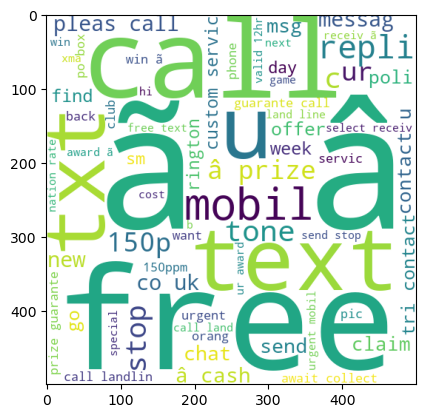

In [91]:
#plt.figure(figsize=(15,6))
plt.imshow(wc)

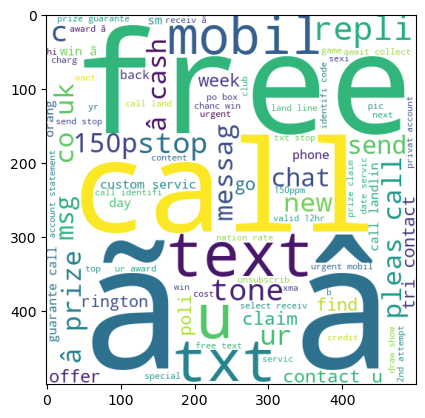

In [92]:
# ye ham sms ke lliye bann ahia 
ham_wc=wc.generate(df[df['target'] == 1]['transfromed_text'].str.cat(sep=" "))
plt.imshow(ham_wc)

In [93]:
spam_corpus = []

for msg in df[df['target'] == 1]['transfromed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)


In [94]:
len(spam_corpus)

12273

In [95]:
from collections import Counter
pd.DataFrame(Counter(spam_corpus).most_common(30))

,0,1
0,call,327
1,â,269
2,ã,259
3,free,195
4,2,184
5,u,146
6,txt,145
7,text,128
8,ur,119
9,mobil,118


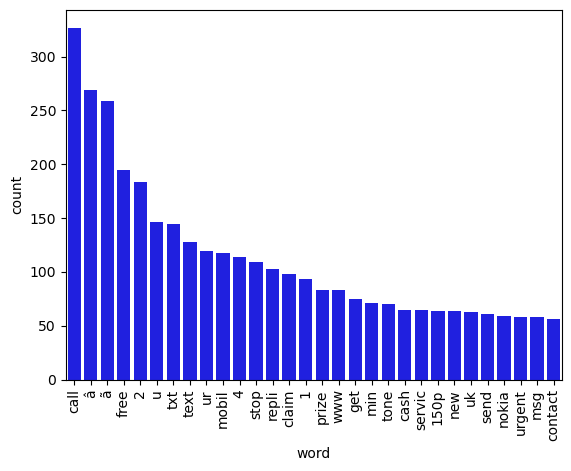

In [96]:
import seaborn as sb
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

# Step 1: Top 30 words
common_words = Counter(spam_corpus).most_common(30)

# Step 2: Convert to DataFrame
df_words = pd.DataFrame(common_words, columns=['word', 'count'])

# Step 3: Plot
sb.barplot(x='word', y='count', data=df_words,color="blue")

plt.xticks(rotation=90,color='black')
plt.show()

In [97]:
ham_corpus = []

for msg in df[df['target'] == 0]['transfromed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)


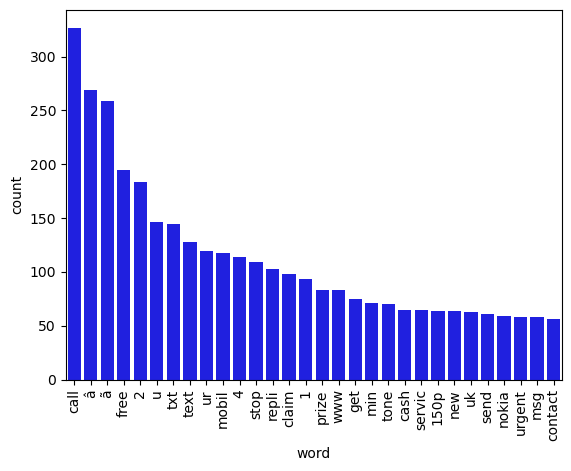

In [98]:
import seaborn as sb
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

# Step 1: Top 30 words
common_words = Counter(spam_corpus).most_common(30)

# Step 2: Convert to DataFrame
df_words = pd.DataFrame(common_words, columns=['word', 'count'])

# Step 3: Plot
sb.barplot(x='word', y='count', data=df_words,color="blue")

plt.xticks(rotation=90,color='black')
plt.show()

Model Building

In [99]:
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib
tfid = TfidfVectorizer()

In [101]:
# FIT HERE 
X = tfid.fit_transform(df['transfromed_text'])

In [ ]:
X = cv.fit_transform(df['transfromed_text']).toarray()

In [102]:
X.shape

(5169, 7214)

In [103]:
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 42727 stored elements and shape (5169, 7214)>

In [104]:
y=df['target'].values

In [105]:
from sklearn.model_selection import train_test_split

In [106]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [107]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [108]:
gnd=GaussianNB()
mlt=MultinomialNB()
bnb=BernoulliNB()

In [109]:
gnd.fit(X_train,y_train)
y_pred1 = gnd.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred1))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred1))
print("Precision:", precision_score(y_test, y_pred1))

TypeError: Sparse data was passed for X, but dense data is required. Use '.toarray()' to convert to a dense numpy array.

In [ ]:
mlt.fit(X_train,y_train)
y_pred1 = mlt.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred1))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred1))
print("Precision:", precision_score(y_test, y_pred1))

In [ ]:
bnb.fit(X_train,y_train)
y_pred1 = bnb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred1))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred1))
print("Precision:", precision_score(y_test, y_pred1))

In [ ]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

gnd = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

# Linear Model
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)

# SVM
from sklearn.svm import SVC
svc = SVC()

# Tree
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()

# Ensemble
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier

rf = RandomForestClassifier()
et = ExtraTreesClassifier()
adb = AdaBoostClassifier()
gb = GradientBoostingClassifier()

# Neighbors
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

In [ ]:
models = {
    "GaussianNB": gnd,
    "MultinomialNB": mnb,
    "BernoulliNB": bnb,
    "LogisticRegression": lr,
    "SVM": svc,
    "DecisionTree": dt,
    "RandomForest": rf,
    "ExtraTrees": et,
    "AdaBoost": adb,
    "GradientBoost": gb,
    "KNN": knn
}

In [ ]:
from sklearn.metrics import accuracy_score, precision_score

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("Model:", name)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("---------------------------")

In [110]:
df.head()

,target,text,num_char,words,num_sent,transfromed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [111]:
import pickle
pickle.dump(tfid,open('vectorizer.pkl','wb'))
pickle.dump(et,open('model.pkl','wb'))